# Notebook 07: Stress Testing

This notebook implements stress testing scenarios:

1. **Historical Stress Scenarios** - COVID crash, 2022 rate hikes, Volmageddon
2. **Hypothetical Scenarios** - Tech crash, rate shock, market crash
3. **Stressed VaR** - VaR under stressed conditions
4. **Scenario Dashboard** - Summary of all stress impacts

---

In [1]:
import numpy as np
import pandas as pd
import json
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)
print("Libraries imported!")

Libraries imported!


In [2]:
# Load configuration
with open('../portfolio_config.json', 'r') as f:
    config = json.load(f)

TICKERS = config['portfolio']['tickers']
WEIGHTS = np.array(config['portfolio']['weights'])
STRESS_SCENARIOS = config['stress_scenarios']
HYPOTHETICAL_SHOCKS = config['hypothetical_shocks']
FACTOR_TICKERS = config['risk_factors']['tickers']

# Load factor betas
with open('../outputs/factor_var_results.json', 'r') as f:
    factor_results = json.load(f)
    BETAS = pd.Series(factor_results['model']['betas'])

print("Configuration loaded!")
print(f"Historical scenarios: {list(STRESS_SCENARIOS.keys())}")
print(f"Hypothetical shocks: {list(HYPOTHETICAL_SHOCKS.keys())}")

Configuration loaded!
Historical scenarios: ['covid_crash', 'rate_hikes_2022', 'volmageddon']
Hypothetical shocks: ['tech_crash', 'rate_shock', 'market_crash', 'vix_spike']


## 7.1 Historical Stress Scenarios

In [3]:
def get_price_data(tickers, start_date, end_date):
    """Download adjusted close prices from Yahoo Finance."""
    data = yf.download(tickers, start=start_date, end=end_date, 
                       auto_adjust=True, progress=False)
    
    # Handle yfinance column structure (MultiIndex or single level)
    if isinstance(data.columns, pd.MultiIndex):
        prices = data['Close']
    else:
        if 'Close' in data.columns:
            prices = data['Close']
        elif 'Adj Close' in data.columns:
            prices = data['Adj Close']
        else:
            prices = data
    
    return prices

def calculate_scenario_loss(tickers, weights, start, end):
    """Calculate portfolio loss during historical stress period."""
    prices = get_price_data(tickers, start, end)
    if len(prices) < 2:
        return None, None, None
    
    # Calculate period return
    start_prices = prices.iloc[0]
    end_prices = prices.iloc[-1]
    asset_returns = (end_prices - start_prices) / start_prices
    
    portfolio_return = (asset_returns * weights).sum()
    max_drawdown = ((prices / prices.cummax() - 1) @ weights).min()
    
    return portfolio_return, max_drawdown, asset_returns

In [4]:
# Calculate losses for each historical scenario
historical_results = []

for scenario_key, scenario_config in STRESS_SCENARIOS.items():
    name = scenario_config['name']
    start = scenario_config['start']
    end = scenario_config['end']
    
    port_return, max_dd, asset_returns = calculate_scenario_loss(TICKERS, WEIGHTS, start, end)
    
    if port_return is not None:
        historical_results.append({
            'Scenario': name,
            'Period': f"{start} to {end}",
            'Portfolio Return': port_return,
            'Max Drawdown': max_dd,
            'Worst Asset': asset_returns.idxmin() if asset_returns is not None else 'N/A',
            'Worst Asset Return': asset_returns.min() if asset_returns is not None else 0
        })

historical_df = pd.DataFrame(historical_results)
display(Markdown("### Historical Stress Scenario Results"))
display(historical_df.style.format({
    'Portfolio Return': '{:.2%}',
    'Max Drawdown': '{:.2%}',
    'Worst Asset Return': '{:.2%}'
}))

### Historical Stress Scenario Results

,Scenario,Period,Portfolio Return,Max Drawdown,Worst Asset,Worst Asset Return
0,COVID-19 Market Crash,2020-02-19 to 2020-03-23,-30.35%,-30.35%,NVDA,-34.58%
1,2022 Fed Rate Hikes,2022-01-01 to 2022-10-12,-39.88%,-40.15%,AMD,-61.64%
2,2018 Volmageddon,2018-02-01 to 2018-02-09,-11.36%,-11.36%,AMD,-15.32%


<cell_type>markdown</cell_type>## 7.2 Hypothetical Stress Scenarios

**Important Note on Methodology:**

For hypothetical stress scenarios, we use two approaches:

1. **Direct Portfolio Beta Approach** - For market-wide shocks (SPY), we estimate the portfolio's 
   beta to SPY directly from historical returns, NOT from the factor model (which may have 
   removed SPY due to multicollinearity).

2. **Factor Model Approach** - For specific factor shocks (XLK, TLT, VIX), we use the 
   factor model betas.

This ensures that a "20% market decline" produces a realistic portfolio impact, even if 
SPY was excluded from the factor model due to correlation with other factors.

In [5]:
def calculate_portfolio_market_beta(portfolio_returns_series, market_ticker='SPY', 
                                      start_date='2022-01-01', end_date='2025-12-03'):
    """
    Calculate the portfolio's beta to the market (SPY) directly.
    This is more robust than using factor model betas when SPY may be excluded.
    """
    import yfinance as yf
    
    # Download SPY returns
    spy_data = yf.download(market_ticker, start=start_date, end=end_date, 
                           auto_adjust=True, progress=False)
    
    if isinstance(spy_data.columns, pd.MultiIndex):
        spy_prices = spy_data['Close'][market_ticker]
    else:
        spy_prices = spy_data['Close']
    
    spy_returns = np.log(spy_prices / spy_prices.shift(1)).dropna()
    
    # Align with portfolio returns
    common_idx = portfolio_returns_series.index.intersection(spy_returns.index)
    port_aligned = portfolio_returns_series.loc[common_idx]
    spy_aligned = spy_returns.loc[common_idx]
    
    # Calculate beta using covariance / variance
    cov = np.cov(port_aligned, spy_aligned)[0, 1]
    var_spy = np.var(spy_aligned)
    beta = cov / var_spy
    
    return beta

def apply_hypothetical_shock(shock_config, factor_betas, portfolio_market_beta):
    """
    Apply hypothetical shock using appropriate methodology.
    
    - For SPY shocks: Use direct portfolio-market beta
    - For other factors: Use factor model betas
    """
    description = shock_config.get('description', 'Unknown')
    total_impact = 0
    
    for factor, shock in shock_config.items():
        if factor == 'description':
            continue
        
        if factor == 'SPY':
            # Use direct portfolio beta to SPY (more accurate)
            impact = portfolio_market_beta * shock
        elif factor in factor_betas.index:
            # Use factor model beta
            impact = factor_betas[factor] * shock
        else:
            impact = 0
        
        total_impact += impact
    
    return total_impact

# Load portfolio returns for beta calculation
portfolio_returns = pd.read_csv('../outputs/portfolio_returns.csv', index_col=0, parse_dates=True)['portfolio_return']

# Calculate portfolio's direct beta to SPY
portfolio_spy_beta = calculate_portfolio_market_beta(portfolio_returns)
print(f"Portfolio Beta to SPY (direct): {portfolio_spy_beta:.4f}")

# Calculate hypothetical scenario impacts using improved methodology
hypothetical_results = []

for scenario_key, shock_config in HYPOTHETICAL_SHOCKS.items():
    description = shock_config.get('description', scenario_key)
    
    total_impact = apply_hypothetical_shock(shock_config, BETAS, portfolio_spy_beta)
    
    shocked_factors = [k for k in shock_config.keys() if k != 'description']
    
    hypothetical_results.append({
        'Scenario': description,
        'Shocked Factors': ', '.join(shocked_factors),
        'Portfolio Impact': total_impact
    })

hypothetical_df = pd.DataFrame(hypothetical_results)
display(Markdown("### Hypothetical Stress Scenario Results"))
display(hypothetical_df.style.format({'Portfolio Impact': '{:.2%}'}))

# Explain methodology
display(Markdown("""
**Methodology Notes:**
- **Market Crash (SPY)**: Uses direct portfolio beta to SPY (not factor model)
- **Tech Crash (XLK)**: Uses factor model beta for tech sector
- **Rate Shock (TLT)**: Uses factor model beta for interest rates
- **VIX Spike**: Uses factor model beta for volatility
"""))

Portfolio Beta to SPY (direct): 1.4720


### Hypothetical Stress Scenario Results

,Scenario,Shocked Factors,Portfolio Impact
0,30% Tech Sector Decline,XLK,-38.80%
1,15% Bond Price Drop (Rate Spike),TLT,0.00%
2,20% Broad Market Decline,SPY,-29.44%
3,150% VIX Increase,^VIX,0.31%



**Methodology Notes:**
- **Market Crash (SPY)**: Uses direct portfolio beta to SPY (not factor model)
- **Tech Crash (XLK)**: Uses factor model beta for tech sector
- **Rate Shock (TLT)**: Uses factor model beta for interest rates
- **VIX Spike**: Uses factor model beta for volatility


## 7.3 Stressed VaR

In [6]:
# Load normal VaR
with open('../outputs/var_results.json', 'r') as f:
    var_results = json.load(f)

normal_var = abs(var_results['historical']['var_1d'])

# Calculate stressed VaR (using stressed volatility from worst scenario)
portfolio_returns = pd.read_csv('../outputs/portfolio_returns.csv', index_col=0, parse_dates=True)['portfolio_return']

# Get volatility during COVID period
covid_period = portfolio_returns['2020-02-01':'2020-04-30']
if len(covid_period) > 0:
    stressed_vol = covid_period.std()
else:
    stressed_vol = portfolio_returns.std() * 2  # 2x normal vol

normal_vol = portfolio_returns.std()
stressed_var = norm.ppf(0.01) * stressed_vol

print("Stressed VaR Analysis")
print("="*50)
print(f"Normal Volatility: {normal_vol:.4%}")
print(f"Stressed Volatility: {stressed_vol:.4%}")
print(f"Volatility Multiple: {stressed_vol/normal_vol:.2f}x")
print(f"\nNormal 99% VaR: {normal_var:.4%}")
print(f"Stressed 99% VaR: {abs(stressed_var):.4%}")
print(f"VaR Increase: {abs(stressed_var)/normal_var:.2f}x")

Stressed VaR Analysis
Normal Volatility: 1.8893%
Stressed Volatility: 3.7785%
Volatility Multiple: 2.00x

Normal 99% VaR: 4.8906%
Stressed 99% VaR: 8.7902%
VaR Increase: 1.80x


## 7.4 Stress Test Dashboard

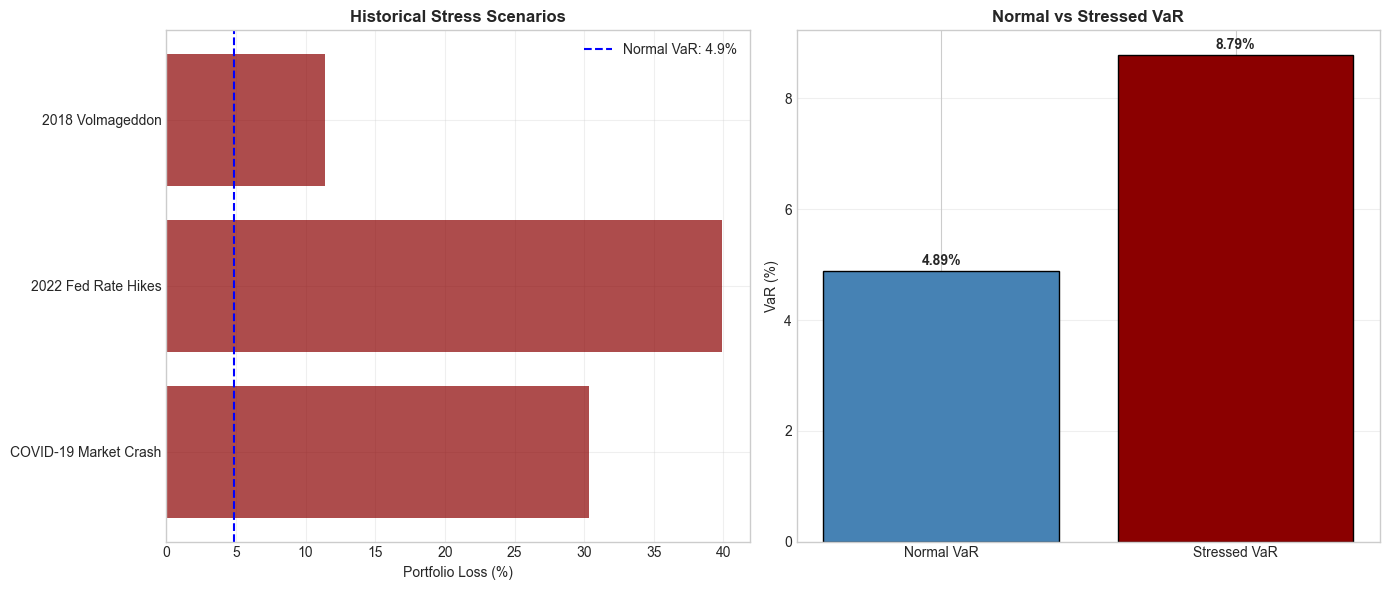

In [7]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Historical scenarios
ax1 = axes[0]
if len(historical_df) > 0:
    scenarios = historical_df['Scenario'].values
    losses = [abs(x)*100 for x in historical_df['Portfolio Return'].values]
    colors = ['red' if x < 0 else 'green' for x in historical_df['Portfolio Return'].values]
    
    bars = ax1.barh(scenarios, losses, color='darkred', alpha=0.7)
    ax1.set_xlabel('Portfolio Loss (%)')
    ax1.set_title('Historical Stress Scenarios', fontweight='bold')
    ax1.axvline(normal_var*100, color='blue', linestyle='--', label=f'Normal VaR: {normal_var:.1%}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

# Right: VaR comparison
ax2 = axes[1]
var_types = ['Normal VaR', 'Stressed VaR']
var_values = [normal_var*100, abs(stressed_var)*100]
colors = ['steelblue', 'darkred']

bars = ax2.bar(var_types, var_values, color=colors, edgecolor='black')
ax2.set_ylabel('VaR (%)')
ax2.set_title('Normal vs Stressed VaR', fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, var_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'{val:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/07_stress_testing.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
# Save stress test results
stress_results = {
    'historical_scenarios': historical_df.to_dict('records') if len(historical_df) > 0 else [],
    'hypothetical_scenarios': hypothetical_df.to_dict('records'),
    'stressed_var': {
        'normal_var': float(normal_var),
        'stressed_var': float(abs(stressed_var)),
        'normal_vol': float(normal_vol),
        'stressed_vol': float(stressed_vol)
    }
}

with open('../outputs/stress_test_results.json', 'w') as f:
    json.dump(stress_results, f, indent=4, default=str)

print("Stress test results saved!")

Stress test results saved!


---
## Summary

This notebook implemented stress testing to assess portfolio vulnerability to extreme market conditions.

**Key Findings:**
- Historical scenarios reveal actual portfolio behavior during past crises
- Hypothetical scenarios quantify impact of specific factor shocks
- Stressed VaR provides conservative risk estimate for capital planning